# RF Data Converter Introduction
----

<div class="alert alert-box alert-info">
Please use Jupyter labs http://board_ip_address/lab for this notebook.
</div>

This notebook presents an introduction to the RF Data
Converters (RF DCs) on the RFSoC4x2 board.

## Aims
* Describe the `xrfdc` Python package that is required to control and
  configure the RF DCs from Jupyter
* Investigate the radio hierarchy in the base overlay, allowing the
  user to develop very simple RF designs. 
* Present the data inspection and visualisation of the RF DCs using 
  Plotly.

## Table of Contents
* [Introduction](#introduction)
* [Hardware Setup](#hardware-setup)
* [The Radio Hierarchy](#radio-hierarchy)
* [Transmitter and Receiver](#the-transmitter-and-receiver)
* [RF Data Inspection](#rf-data-inspection)
* [Conclusion](#conclusion)

## References
* [Xilinx, Inc, "USP RF Data Converter: LogiCORE IP Product Guide", PG269, v2.4, November 2020](https://www.xilinx.com/support/documentation/ip_documentation/usp_rf_data_converter/v2_4/pg269-rf-data-converter.pdf)
* [Xilinx, Inc, "Vivado Design Suite: The AXI Reference Guide", UG1037, v4.0, June 2017](https://www.xilinx.com/support/documentation/ip_documentation/axi_ref_guide/latest/ug1037-vivado-axi-reference-guide.pdf)

## Revision History

* v1.0 | 25/02/2022 | First notebook revision.

----

## Introduction <a class="anchor" id="introduction"></a>

An overview of the Zynq RFSoC device is shown below; there are
three major components:

* Processing System (PS)
* Programmable Logic (PL)
* RF Data Converters (RF DC, including ADC and DAC)

The RF data converters are significant features of the Zynq RFSoC
device as they interface directly to the PL.
This brings many advantages, including the ability to
perform direct RF sampling and low-latency processing.
The RFSoC4x2 is a Gen 3 RFSoC platform consisting of an XCZU48DR-FSVG1517-2-E RFSoC device.
This RFSoC device has 8 RF ADC channels and 8 RF DAC channels. However, only the following
is accessible on the RFSoC4x2 development board.

* 4x RF Analogue-to-Digital Converters (RF ADCs)
    * Sample rate of 5 GSPS
    * 14-bit conversion
* 2x RF Digital-to-Analogue Converters (RF DACs)
    * Sample rate of 9.85 GSPS
    * 14-bit conversion

<img src='data/rfsystem_rfdc_overview.png' align='left' style='left' height='75%' width='75%'/>

Let's take a closer look at the RF DC block, starting with
the RF ADC tiles. Each tile contains 2 RF ADC blocks, 
which can be used to receive, or Digital Down Convert (DDC), 
an analogue signal. Each RF ADC block contains:

* A gearbox FIFO
* 1x (bypass), 2x, 3x, 4x, 5x, 6x, 8x, 10x, 12x, 16x, 20x, 24x or 40x decimator
* A complex mixer
* A Quadrature Modulation Correction (QMC) unit
* Embedded Digital Step Attenuator (DSA)
* On-chip clock distribution network

The image below presents the typical RF ADC processing 
pipeline:

1. The RF ADC samples the input waveform to convert it
   into a digital signal.
2. A threshold detector can be employed to detect and record
   input amplitude levels. 
3. The QMC is used to offset potential imbalance in the
   quality of the received complex signal.
4. The I and Q mixer can mix the input signal to baseband.
5. The I and Q decimators are capable of a wide range of
   decimation options before interfacing the PL via the gearbox FIFO.

<img src='data/rfsystem_rfadc_block_overview.png' align='left' style='left' height='100%' width='100%'/>

The RF DAC block has a similar pipeline to the RF ADC;
however, it is in reverse this time for Digital Up Conversion (DUC).

1. The data to be transmitted is interfaced to the RF DAC block from the PL.
2. The digital signal is interpolated by a factor of 1x (bypass), 2x, 3x, 4x, 5x, 6x, 8x, 10x, 12x, 16x, 20x, 24x    or 40x.
3. The digital signal is transferred to the complex mixer to be mixed
   to the desired carrier frequency. 
4. The signal then passes through an Image Rejection (IMR), which is capable of removing images in either the 1st or 2nd Nyquist zones. The IMR provides an additional 2x interpolation that can be bypassed if required.
5. After the IMR filter stage, the signal can optionally
   be convolved with an inverse (anti) sinc filter to improve the
   roll-off of the first Nyquist zone.
6. The digital signal is then converted to analogue through the
   RF DAC sampler.


<img src='data/rfsystem_rfdac_block_overview.png' align='left' style='left' height='100%' width='100%'/>

In this notebook, we will be demonstrating many of the features
mentioned above via a simple loopback example.

## Hardware Setup <a class="anchor" id="hardware-setup"></a>

The RFSoC4x2 board contains 4 RF ADC channels and 2 RF DAC channels. For this demonstration, we will be using 2 RF ADC channels and 2 RF DAC channels in loopback.

Make the loopback connection, using SMA cables, as shown below:

* Channel 3: DAC A to ADC A
* Channel 2: DAC B to ADC B

See the image below for a demonstration.

<img src='data/rfsoc4x2_loopback.jpg' align='left' style='left' height='75%' width='75%'/>

<div class="alert alert-heading alert-danger">
    <h4 class="alert-heading">Warning:</h4>

In this demo we are transmitting signals via cables.
This device can also transmit wireless signals. 
Keep in mind that unlicensed transmission of wireless signals
may be illegal in your location. 
Radio signals may also interfere with nearby devices,
such as pacemakers and emergency radio equipment. 
If you are unsure, please seek professional support.
</div>

----

## The Radio Hierarchy <a class="anchor" id="radio-hierarchy"></a>

We need to add custom control logic in the PL to communicate
with the RF ADC or RF DAC. The RFSoC4x2 base overlay contains
such logic that will allow you to evaluate the RF DCs. 
There are two IP Cores - the transmitter and the receiver.

* **Amplitude Controller** - can apply a value to the input of the RF DAC.
The value can be set by writing to an AXI-Lite register. 
The register value can be mixed with the Numerically
Controlled Oscillator (NCO) in the fine mixer to create a tone. 
The tone is looped back round into the RF ADC.

* **Packet Generator** - interfaces to the output of RF ADC block. 
The data is used to generate an [AXI-Stream packet](https://www.xilinx.com/support/documentation/ip_documentation/axi_ref_guide/latest/ug1037-vivado-axi-reference-guide.pdf).
The AXI-Stream packet is sent to an AXI Direct Memory
Access (DMA) core and transferred to DDR memory.

These 2 IP cores are connected to each channel of the RFSoC4x2 board.
They are conveniently placed inside a hierarchical block, `radio`, 
as shown below.

<img src='data/rfsystem_introduction.png' align='left' style='left' height='75%' width='75%'/>

In [1]:

# 1. Load Design and Initialize Objects
import numpy as np
import matplotlib.pyplot as plt
from pynq import Overlay, allocate
from scipy.signal import windows
import xrfdc
ol = Overlay('dac_adc.bit') # From your working DAC code
rfdc = xrfdc.RFdc(ol.ip_dict['usp_rf_data_converter_0'])
dma = ol.axi_dma_0 # From your working ADC code

# Identify target tiles
dac_block = rfdc.dac_tiles[0].blocks[0] # DAC 228
adc_block = rfdc.adc_tiles[2].blocks[0] # ADC 226




In [2]:
print(ol.ip_dict.keys())

dict_keys(['axi_dma_0', 'axi_intc_0', 'usp_rf_data_converter_0', 'zynq_ultra_ps_e_0'])


In [2]:
print(dac_block.MixerSettings)

{'Freq': 99.99999999999417, 'PhaseOffset': 0.0, 'EventSource': 2, 'CoarseMixFreq': 16, 'MixerMode': 2, 'FineMixerScale': 0, 'MixerType': 2}


In [30]:
#mixer settings code

import xrfdc

# Manually bind the RFDC driver to the IP block
rfdc = xrfdc.RFdc(ol.ip_dict['usp_rf_data_converter_0'])

# Now the high-level attributes should work
target_block = rfdc.dac_tiles[0].blocks[0]

def update_nco(rf_block, nco_freq):
    mixer_cfg = rf_block.MixerSettings
    mixer_cfg['Freq'] = nco_freq
    rf_block.MixerSettings = mixer_cfg
    rf_block.UpdateEvent(xrfdc.EVENT_MIXER)

update_nco(target_block, 100)
print("Success! NCO updated.")

Success! NCO updated.


In [3]:
#sine wave code



from pynq import allocate
import numpy as np

# 1. Allocate a DMA-safe buffer
data_size = 1024
# Ensure the dtype matches your DAC (likely 'u2' for 14-bit/16-bit unsigned)
input_buffer = allocate(shape=(data_size,), dtype='u2')

# 2. Generate the Sine Wave directly into the allocated buffer
amplitude = 33800   #8048==223mV , 16383==460mV , 32000==910mV , 32766==920mV
offset = amplitude
frequency = 0
t = np.arange(data_size)

# Calculate and copy into the PYNQ buffer
sine_data = (amplitude * np.sin(2 * np.pi * frequency * t / data_size) + offset).astype(np.uint16)
np.copyto(input_buffer, sine_data)

# 3. The DMA transfer loop
try:
    while True:
        dma.sendchannel.transfer(input_buffer)
        dma.sendchannel.wait()
except KeyboardInterrupt:
    print("Transfer stopped by user.")


Transfer stopped by user.


In [ ]:
#square wave code


import numpy as np

data_size = 1000
input_buffer = allocate(shape=(data_size), dtype=np.uint32)

# Square wave parameters (in hex)
high_val = 0xFFFE   # Max 14-bit value
lev3_val = 0x5555
lev2_val = 0x2AAB
low_val  = 0x000   # Min value
period   = 8       # Number of samples per full wave cycle

for i in range(data_size):
#    if (i % period) < (period // 4):
#        input_buffer[i] = high_val
#    elif (i % period) < (period // 2):
#        input_buffer[i] = lev3_val
#    elif (i % period) < (3 * period // 4):
#        input_buffer[i] = lev2_val
#    else:
#        input_buffer[i] = low_val
     if (i % period) < (period // 2):
         input_buffer[i] = high_val
     else:
         input_buffer[i] = low_val
#    input_buffer[i] = 2**15-1


# Print first 10 values in hex
for i in range(10):
    print(hex(input_buffer[i]))
try:
    while True:
        dma.sendchannel.transfer(input_buffer)
        dma.sendchannel.wait()
except KeyboardInterrupt:
    print("Transfer stopped by user.")

0xfffe
0xfffe
0xfffe
0xfffe
0x0
0x0
0x0
0x0
0xfffe
0xfffe


In [7]:
from pynq import allocate
import numpy as np
import matplotlib.pyplot as plt

# 1. Allocate a DMA-safe buffer for capture
# Using 'u2' to match your DAC code's unsigned 16-bit format
# Ensure data_size is a multiple of 8 for alignment
capture_size = 16384 
adc_buffer = allocate(shape=(capture_size,), dtype='u2')

# 2. Capture Function
def capture_wave():
    # Start the DMA receive channel transfer
    dma.recvchannel.transfer(adc_buffer)
    dma.recvchannel.wait()
    
    # Copy to a numpy array for processing
    return np.array(adc_buffer)

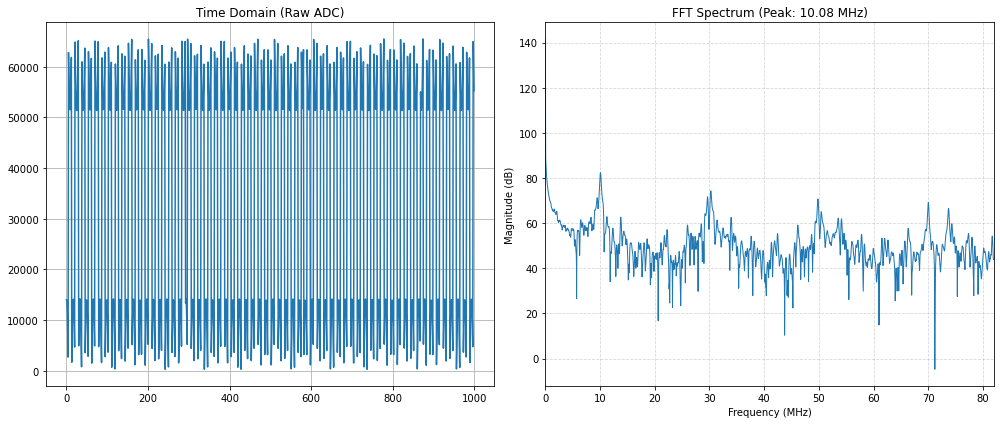

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# --- HARDWARE CONSTANTS ---
# 4915.2 GSPS / 3 (Decimation) = 1638.4 MSPS
ADC_SAMPLE_RATE_MSPS = 163.84 

def get_clean_fft(data, num_averages=1):
    # 1. Remove DC Offset and apply Blackman-Harris window
    # This removes the "square wave" harmonics and spectral leakage
    centered_data = data.astype(np.float32) - np.mean(data)
    win = windows.blackmanharris(len(centered_data))
    windowed_signal = centered_data * win
    
    # 2. Perform FFT
    n = len(windowed_signal)
    fft_res = np.fft.fft(windowed_signal)
    freqs = np.fft.fftfreq(n, 1/(ADC_SAMPLE_RATE_MSPS * 1e6))
    
    # 3. Clean Peak Detection (Skip first 20 bins to ignore DC)
    ignore_bins = 30
    pos_freqs = freqs[ignore_bins:n//2] / 1e6
    pos_mag = np.abs(fft_res[ignore_bins:n//2])
    peak_freq = pos_freqs[np.argmax(pos_mag)]
    
    return freqs[:n//2]/1e6, 20*np.log10(np.abs(fft_res[:n//2]) + 1e-9), peak_freq

# Execute Capture and Analysis
raw_adc_data = capture_wave()
f_axis, mag_axis, detected_f = get_clean_fft(raw_adc_data)

# --- VISUALIZATION ---
plt.figure(figsize=(14, 6))

# Subplot 1: Time Domain (Center around 0)
plt.subplot(1, 2, 1)
plt.plot(raw_adc_data[:1000]) # Zoomed view to see waves
plt.title('Time Domain (Raw ADC)')
plt.grid(True)

# Subplot 2: Cleaned Frequency Domain
plt.subplot(1, 2, 2)
plt.plot(f_axis, mag_axis, color='tab:blue', linewidth=1)
plt.title(f'FFT Spectrum (Peak: {detected_f:.2f} MHz)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Magnitude (dB)')
plt.xlim([0, 81.92]) # Set to the Nyquist limit
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [37]:
# Printing first 5 cycles of 128-bit data (8 samples each)
print(f"\nComparing 128-bit Packets (Effective fs: {effective_fs} MSPS)")
print("-" * 80)
print(f"{'Cycle':<8} | {'TX Packet (Hex)':<32} | {'RX Packet (Hex)':<32}")
print("-" * 80)

for i in range(5):
    # Get 8 samples for one 128-bit clock cycle
    tx_p = input_buffer[i*8 : (i+1)*8]
    # Note: RX packet will be shifted by the hardware 'lag'
    rx_p = adc_buffer[(i*8)+offset : ((i+1)*8)+offset] 
    
    tx_hex = "".join(f"{s:04x}" for s in reversed(tx_p))
    rx_hex = "".join(f"{s:04x}" for s in reversed(rx_p))
    
    print(f"  {i:<5}  | 0x{tx_hex} | 0x{rx_hex}")


Comparing 128-bit Packets (Effective fs: 1638.3999999999999 MSPS)
--------------------------------------------------------------------------------
Cycle    | TX Packet (Hex)                  | RX Packet (Hex)                 
--------------------------------------------------------------------------------
  0           | 0x84088408840884088408840884088408 | 0x
  1           | 0x84088408840884088408840884088408 | 0x
  2           | 0x84088408840884088408840884088408 | 0x
  3           | 0x84088408840884088408840884088408 | 0x
  4           | 0x84088408840884088408840884088408 | 0x
  5           | 0x84088408840884088408840884088408 | 0x
  6           | 0x84088408840884088408840884088408 | 0x
  7           | 0x84088408840884088408840884088408 | 0x
  8           | 0x84088408840884088408840884088408 | 0x
  9           | 0x84088408840884088408840884088408 | 0x


The RF-ADC block mixer frequency can also be tuned. We set it to 1228.8 MHz as
that is the default setting. This is a suitable mixer frequency for the
next part of the demonstration, where we will transfer time domain samples
from receiver channels.

Firstly, we will define the numbers of samples to be transferred. 
The range of samples that can be transferred is between 16 to 32768.
Running the code cell below, will transfer complex data, with an amplitude of 1.